# Confidence and prediction intervals

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/regression/03-confidence-and-prediction-intervals.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

The purpose of fitting a model is to make predictions.
The previous notebook quantified uncertainty in the fitted model parameters, i.e., the slope and intercept. 
In this notebook, we will discuss how these uncertainties translate to uncertainty in the predictions.

At an ambient temperature of 20°C, we might ask:

- What is the **average NOx concentration** at this temperature?
- What NOx concentration might we observe during **one additional operating hour**?

The same fitted line supplies a point estimate for both questions, but their uncertainty differs.

**Learning objectives**

- Distinguish a coefficient confidence interval, a mean-response confidence interval, and a prediction interval.
- Explain why a prediction interval is wider than a mean-response confidence interval.
- Calculate and plot both intervals for the NOx–AT model.
- Identify the assumptions behind these intervals.


## 1. Reproduce the temperature–NOx model

We use the same hourly gas-turbine measurements as before. **AT** is ambient temperature (°C), and **NOX** is nitrogen-oxides concentration in the exhaust (mg/m³). The setup below lets this notebook run independently, including in Colab.


In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 12})

# Use the local course CSV when available; download it in Colab if needed.
DATA_URL = "https://raw.githubusercontent.com/changyaochen/MECE4520/master/site/data/gas-turbine-course.csv"
candidates = [
    Path("../data/gas-turbine-course.csv"),
    Path("site/data/gas-turbine-course.csv"),
    Path("gas-turbine-course.csv"),
]
data_path = next((path for path in candidates if path.exists()), candidates[-1])
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)

data = pd.read_csv(data_path)
regression_data = data[["AT", "NOX"]].dropna()
x = regression_data["AT"]
y = regression_data["NOX"]

# Add an intercept and fit using all available AT–NOx pairs.
model = sm.OLS(y, sm.add_constant(x)).fit()
intercept = model.params["const"]
slope = model.params["AT"]
n = len(x)
x_bar = x.mean()
sxx = ((x - x_bar) ** 2).sum()
s = np.sqrt((model.resid ** 2).sum() / (n - 2))

print(f"Observations: {n:,}")
print(f"Fitted line: NOx = {intercept:.2f} {slope:+.3f} × AT")
print(f"Residual SD: {s:.2f} mg/m³")


Observations: 36,733
Fitted line: NOx = 80.80 -0.875 × AT
Residual SD: 9.69 mg/m³


## 2. One point prediction, two questions

Write the population model as

$$
Y_i = \beta_0 + \beta_1 x_i + \varepsilon_i.
$$

With mean-zero errors, the population mean response at a chosen temperature $x_0$ is.

$$
m(x_0) = \beta_0 + \beta_1 x_0.
$$

That is, if we make many observations at temperature $x_0$, 
the average NOx concentration will be $m(x_0)$ as the error term averages out.
In the above equation, the population parameters $\beta_0$ and $\beta_1$ are unknown, 
so we estimate them using the sample coefficients $\hat{\beta}_0$ and $\hat{\beta}_1$:

$$
\hat{m}(x_0) = \hat{\beta}_0 + \hat{\beta}_1 x_0.
$$

Here $m(x_0)$ is the unknown **average** NOx at that single temperature, not the average across all temperatures. 
An **individual** new observation will have an additional error source coming from the random noise $\varepsilon_i$.

$$
Y_{\mathrm{new}} = m(x_0) + \varepsilon_{\mathrm{new}}.
$$

Even if we knew the population parameters exactly, an individual prediction would still vary around.


In [2]:
x0 = 20.0
mean_prediction = intercept + slope * x0
print(f"At AT = {x0:.1f}°C, predicted NOx = {mean_prediction:.2f} mg/m³")


At AT = 20.0°C, predicted NOx = 63.29 mg/m³


## 3. A confidence interval for the mean response

Let's focus on the mean response $m(x_0)$ first. 
As mentioned, its uncertainty (i.e., variance) originates from the fitted model parameters. 
As such, its estimated standard error is
 
$$
SE_{\mathrm{mean}}(x_0)
= s\sqrt{\frac{1}{n} + \frac{(x_0-\bar{x})^2}{S_{xx}}},
\qquad
S_{xx} = \sum_i(x_i-\bar{x})^2.
$$

We will not dive into the exact derivation here, but rather want to build some intuitions. 

1. The $1/n$ term shrinks as we collect more observations. Therefore, more (training) data leads to a more precise estimate of the mean response.
2. The second term increases as we move away from the average observed temperature. Therefore, a prediction at extreme values (away from the majority of the training data) will be more uncertain.

As in the previous notebook, we use the large-sample Normal critical value $z^* \approx 1.96$. The 95% confidence interval is

$$
\hat{m}(x_0) \pm 1.96\,SE_{\mathrm{mean}}(x_0).
$$

This is an interval for the **population mean response at $x_0$**.

> If we repeatedly collected comparable datasets and constructed this interval at the same temperature, approximately 95% of the intervals would contain the true mean response there, provided the model assumptions hold.


## 4. A prediction interval for one new observation

Predicting a new operating hour has two sources of uncertainty:

- We estimated the population parameters from the collected samples.
- The new prediction has its own random deviation from observation.

If the new error is independent of the data used to fit the model, so their variances are additive. 
The estimated standard deviation of the prediction error is

$$
SE_{\mathrm{prediction}}(x_0)
= s\sqrt{1 + \frac{1}{n} + \frac{(x_0-\bar{x})^2}{S_{xx}}}.
$$

The extra **1** inside the square root contributes $s^2$ to the prediction-error variance. 
It represents the variation of a new observation around the population line.

Assuming approximately Normal errors, the large-sample 95% prediction interval is

$$
\hat{m}(x_0) \pm 1.96\,SE_{\mathrm{prediction}}(x_0).
$$

> Across repeated data collections and independent new observations at the same temperature, approximately 95% of these prediction intervals would contain the corresponding new observation, under the model assumptions.


In [3]:
# Both intervals share the same center, but use different uncertainty scales.
z_star = norm.ppf(0.975)
mean_se = s * np.sqrt(1 / n + (x0 - x_bar) ** 2 / sxx)
prediction_se = s * np.sqrt(1 + 1 / n + (x0 - x_bar) ** 2 / sxx)

interval_table = pd.DataFrame({
    "Point estimate (mg/m³)": [mean_prediction, mean_prediction],
    "Lower bound (mg/m³)": [
        mean_prediction - z_star * mean_se,
        mean_prediction - z_star * prediction_se,
    ],
    "Upper bound (mg/m³)": [
        mean_prediction + z_star * mean_se,
        mean_prediction + z_star * prediction_se,
    ],
}, index=["95% CI: mean response", "95% PI: one new hour"])
interval_table.round(3)


,Point estimate (mg/m³),Lower bound (mg/m³),Upper bound (mg/m³)
95% CI: mean response,63.291,63.187,63.395
95% PI: one new hour,63.291,44.299,82.283


## 5. Compare the intervals across temperatures

We can repeat the calculation over the observed temperature range. Each vertical slice of the confidence band is a **pointwise** 95% interval at that temperature; it is not a simultaneous 95% confidence statement about the entire line.

The left panel shows both bands against the hourly measurements. The right panel subtracts the fitted line from the mean-response confidence limits so that the narrow confidence band remains visible. Its vertical axis therefore shows **uncertainty around the fitted mean**, not the raw NOx concentration or the residuals.


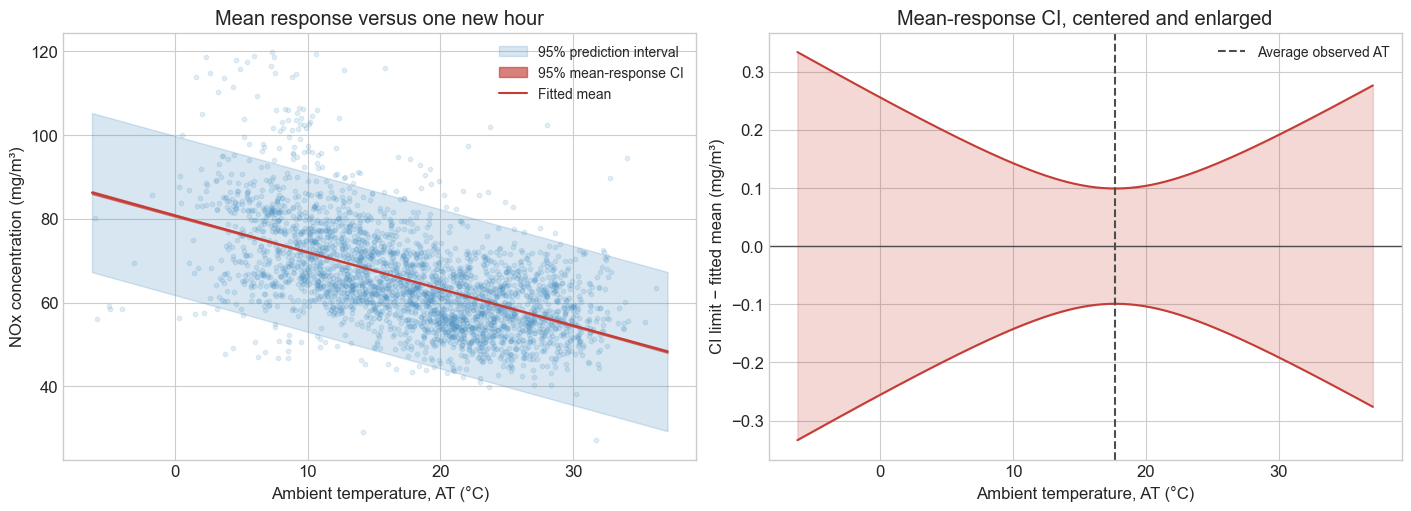

In [4]:
# Evaluate the fitted line at 250 evenly spaced temperatures within the data range.
temperature_grid = np.linspace(x.min(), x.max(), 250)
fitted_mean = intercept + slope * temperature_grid

# Compute uncertainty in the estimated mean at each temperature.
mean_se_grid = s * np.sqrt(1 / n + (temperature_grid - x_bar) ** 2 / sxx)
# The extra 1 adds the variation of one new hour around the population line.
prediction_se_grid = s * np.sqrt(1 + 1 / n + (temperature_grid - x_bar) ** 2 / sxx)
# Multiplying by about 1.96 gives the distance from the center to each 95% limit.
ci_half_width = z_star * mean_se_grid
pi_half_width = z_star * prediction_se_grid

# Only the scatterplot is subsampled; the fit and intervals use all rows.
plot_data = regression_data.sample(n=min(3000, n), random_state=4520)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Left panel: show the observations and both intervals on the original NOx scale.
ax = axes[0]
ax.scatter(plot_data["AT"], plot_data["NOX"], s=10, alpha=0.15,
           color="#4a90c2", rasterized=True)
# fill_between shades the area between the lower and upper limits.
# Draw the wider PI first, then the narrower CI; alpha controls transparency.
ax.fill_between(temperature_grid, fitted_mean - pi_half_width,
                fitted_mean + pi_half_width, color="#4a90c2", alpha=0.22,
                label="95% prediction interval")
ax.fill_between(temperature_grid, fitted_mean - ci_half_width,
                fitted_mean + ci_half_width, color="#c43c35", alpha=0.65,
                label="95% mean-response CI")
ax.plot(temperature_grid, fitted_mean, color="#c43c35", linewidth=1.5,
        label="Fitted mean")
ax.set(xlabel="Ambient temperature, AT (°C)",
       ylabel="NOx concentration (mg/m³)",
       title="Mean response versus one new hour")
ax.legend(fontsize=10)

# Right panel: the CI is too narrow to see clearly on the left.
# Subtracting the fitted mean leaves limits of ±ci_half_width around zero.
# This panel uses its own y-axis scale; these are not observation residuals.
ax = axes[1]
ax.fill_between(temperature_grid, -ci_half_width, ci_half_width,
                color="#c43c35", alpha=0.2)
ax.plot(temperature_grid, ci_half_width, color="#c43c35")
ax.plot(temperature_grid, -ci_half_width, color="#c43c35")
ax.axhline(0, color="#4d4d4d", linewidth=1)
# The mean-response CI is narrowest at the average observed temperature.
ax.axvline(x_bar, color="#4d4d4d", linestyle="--", label="Average observed AT")
ax.set(xlabel="Ambient temperature, AT (°C)",
       ylabel="CI limit − fitted mean (mg/m³)",
       title="Mean-response CI, centered and enlarged")
ax.legend(fontsize=10)
plt.show()


The mean-response confidence band is very narrow because we have many observations. The prediction band remains much wider because individual hours still vary around the line.

Both bands are narrowest at $\bar{x}$. The prediction band's change in width may be hard to see here because the individual-hour variation dominates the uncertainty in the fitted mean.

### Try it

Change the temperature below to another value **within the observed range**. Before running it, predict whether the mean-response CI will be wider or narrower than at 20°C.


In [5]:
# Uncomment and choose a temperature to compare intervals.
# new_temperature = 30.0
# new_mean = intercept + slope * new_temperature
# new_mean_se = s * np.sqrt(1 / n + (new_temperature - x_bar) ** 2 / sxx)
# new_prediction_se = s * np.sqrt(1 + 1 / n + (new_temperature - x_bar) ** 2 / sxx)
# print("Mean-response CI:", new_mean + np.array([-1, 1]) * z_star * new_mean_se)
# print("Prediction interval:", new_mean + np.array([-1, 1]) * z_star * new_prediction_se)


## 6. What these intervals do not guarantee

These calculations assume an adequate linear mean relationship, independent errors, and a common error variance. The prediction interval also assumes approximately Normal individual errors and a new hour from the same observation process.

The residual diagnostics in our first regression notebook give reasons to question this simple model. Hourly plant measurements may also be dependent. Treat these as **model-based teaching intervals**, not validated guarantees for plant operation.

- A narrow confidence interval does not fix a wrong model.
- Extrapolation can fail even if the formula returns an interval.
- More data can make the fitted mean precise without making an individual hour predictable.

## Check-in

1. An operator asks for the average NOx at 20°C. Which interval answers that question?
2. Why would a prediction interval remain wide even if we knew the population line exactly?
3. Does a 95% mean-response confidence band mean that it should contain 95% of the hourly observations?

[Return to the Regression page](index.qmd)
